# MALDI Data Input and Preprocessing
<b>Author:</b> Annalena Weissert\
<b>Last Edited:</b> 16 July 2026 

<b>Input:</b> Raw Data, see "ExampleData_Raw/README.txt" for the data format that is assumed in this code\
<b>Output:</b> Processed PyTorch tensors (.pt). One .pt file for each sample (here: tumor specimen). Filename will be the same as the raw data folder for each sample.

<b>Note: </b>Commands where (relative) paths or filenames may need to be adjusted are marked with '#!'. If the directory structure is kept as in github, the code should work on the Example Data without adjustment.



In [1]:
## Packages
import os        
import numpy as np
import torch
import math         # for gcd and floor 
import glob         # for file (name) assessing
import cv2          # image handling
import torchvision.transforms as v2 # rescale tensors
import matplotlib.pyplot as plt     # visualization

raw_data_path = "ExampleData_Raw"              #! Relative path to the raw data folder
toy_data_path = "ExampleData_Raw/ToyTumor"     #! Relative path to the Toy Tumor folder, which serves as a minimal example to showcase and test run functions. 
                                               #  The foldername "ToyTumor" should not be changed, as it is accessed within the code
processed_data_path = "ExampleData_Processed"  #! Relative path to the folder where the processed data will be saved


## Function Definition

In [2]:
## Function to input intensity (colData) csv table
# Input: File path. Data format: mz (rows) x spotID (cols). Order of spot id's matching those of spots table.
#       skip rows: How many rows at the beginning of the documents should be skipped (for our data format 10)
#       output_names: shall vectors with mz and spot names be returned (e.g. to check/reference order) -> True, or just the intensity matrix -> False
# Output: 2D numpy array mz x spots, without row or colnames. If output_names=True additionally one vector with rownames and one with colnames 
def read_int(int_path, skip_rows=10, output_names = False):
    int_matrix = np.loadtxt(int_path, delimiter=";",skiprows=skip_rows, dtype="str") 
    mz_names = int_matrix[1:,0] # Skip first entry in the top left corner, save rownames
    spot_names = int_matrix[0,1:] # Skip first entry in the top left corner, save colnames
    int_matrix = int_matrix[1:,1:].astype(float) # delete first column and row with mz/spot names 

    if(output_names):
        return int_matrix, mz_names, spot_names 
    
    return int_matrix

## Function to input spots (Reg) csv table
# Input: File path. Data format: spots (rows) x coordinate x, y (cols)
#       skip rows: How many rows at the beginning of the documents should be skipped (for our data format 8)
#       output_names: shall vectors with spot names be returned (e.g. to check/reference order) -> True, or just the intensity matrix -> False
# Output 2D numpy array spots x [x,y], without row or colnames. If output_spots=True additionally one vector with rownames 
def read_spots(spots_path, skip_rows = 8, output_spot = False):
    spot_matrix = np.loadtxt(spots_path, delimiter=";",skiprows=skip_rows, dtype="str") 
    spot_names = spot_matrix[1:,0] # Skip first entry: "m/z"
    spot_matrix = spot_matrix[1:,1:].astype(float) # delete first column and row with mz/spot names 

    if(output_spot):
        return spot_matrix, spot_names
    return spot_matrix

In [3]:
## Test run on Toy Data 
# Note on Toy Data: Very simplified data example. Only containing 3 m/z-values and 9 spots for testing and showcasing functions.
path_toy_int = "".join([toy_data_path, "/ToyTumor_colData.csv"])
path_toy_spot = "".join([toy_data_path, "/ToyTumor_Reg.csv"])
int1 = read_int(path_toy_int, 0)
spot1 = read_spots(path_toy_spot, 0)
print("ToyTumor \nIntensity:\n",int1,"\nSpots:\n",spot1)

ToyTumor 
Intensity:
 [[  0.   5.   0. 250.   0.  20.  20.  70.  20.]
 [  0. 150.   0.  30.  20.   5. 150. 300.  15.]
 [100.   0.  60.  40.  40.   5. 500. 200.   0.]] 
Spots:
 [[40. 30.]
 [41. 30.]
 [42. 30.]
 [40. 31.]
 [41. 31.]
 [42. 31.]
 [40. 32.]
 [41. 32.]
 [42. 32.]]


### Preprocess Spots matrix
Scale x-y-coordinates to fit in a pixel-matrix 

In [4]:
## Function to check whether the distances between x or y values are equidistant throughout. 
# Input: pandas data frame and variable name ("x" or "y")
# Output: If equidistant: distance value, If not: Error-message and "False"
def is_equi_distant(spot_matrix, var=0): #0 = "x", 1 = "y"
    unique = np.unique(np.sort(spot_matrix[:,var])) # order var-values increasing
    n = len(unique)
    diff = np.unique(unique[1:] - unique[:(n-1)]) # calculate distance between x_(n) and x_(n-1) 
    if(len(diff) == 1): # check if distance always the same/unique 
        var_dist = diff.item()
    else:
        print("The distances between",["x","y"][var],"values differ:", diff)
        print("dist is set to greatest common divisor", math.gcd(*diff.astype(int)), "- Missing spots during 'melt-step' are set to 0")
        var_dist = math.gcd(*diff.astype(int))
    return var_dist  

## Function to rescale equidistant pandas df / spot matrix to set coordinates from 0 to max for x and y values.
# Input: pandas data frame and variable name ("x" or "y")
# Output: If equidistant: distance value, If not: Error-message and "False"
def rescale_spots(spot_matrix_input):
    spot_matrix = np.round(spot_matrix_input,0)

    dist_x = is_equi_distant(spot_matrix = spot_matrix, var=0)
    dist_y = is_equi_distant(spot_matrix = spot_matrix, var=1)
    if( not dist_x == dist_y):
        print("!Warning! x and y equidistant respecitvely, but different from each other. x-dist:",dist_x,", y-dist:",dist_y, "\n Spots scaled by smaler one.")
    dist = min(dist_x,dist_y)    
    spot_matrix[:,0] = (spot_matrix[:,0] - min(spot_matrix[:,0])) / dist
    spot_matrix[:,1] = (spot_matrix[:,1] - min(spot_matrix[:,1])) / dist
    
    spot_matrix = spot_matrix.astype(int)

    return spot_matrix  

In [5]:
## Test run on Toy Data 
#  If the spots were not equidistant, the function would print a warning
rescale_spots(spot1)

array([[0, 0],
       [1, 0],
       [2, 0],
       [0, 1],
       [1, 1],
       [2, 1],
       [0, 2],
       [1, 2],
       [2, 2]])

### Melt Spots and Intenisty Data into one data frame

For BYOL the following shape is required: quadratic images, all sharing the same size (-> use maximum x & y of all training tumors)

ImageBatch dimensions: (img number, 3 , size, size) 
In our case img number is the m/z values and 3 color channels are required (for greyscale images clone single color channel to three)

In [6]:
## Dimension of Toy Example
max_size = np.max(rescale_spots(spot1))
print("max_size:",int(max_size), "(+1)") # +1 if zero is counted
number_mz = int1.shape[0]
print("m/z number:",number_mz)

max_size: 2 (+1)
m/z number: 3


*Melt_spot_and_int*: Fuse intensity matrix with spot matrix. Write intensities in a zero square matrix, afterwards resize to a fixed size.

Why padding parameter? Pytorch's Resnet50 IMAGENET1K_V2 preprocessing resizes images to 232, then center crops them to 224. Thus to not lose our border pixels we scale the tumor to 224 x 224 and have 4 zero-pixels on each side around it.\
Source: https://docs.pytorch.org/vision/main/models/generated/torchvision.models.resnet50.html (Accessed: 02 July 2026)

In [7]:
def melt_spot_and_int(spot_matrix_input, int_matrix_input, resize=224, padding=4): # Resize: Size of the tumor; padding: will be added to each border - see note above 
    # Rescale spots
    spot_coord = rescale_spots(spot_matrix_input)

    max_size = int(np.max(spot_coord)) + 1 # Maximum of x and y (+1 to account for starting at 0). Calculate size of this tumor
    print("MALDI scan has dimensions:",np.max(rescale_spots(spot_coord),axis=0)+1, end=" ")

    number_mz = int(int_matrix_input.shape[0]) # rows of int = number of mz
    print("\nThe number of m/z-values is", number_mz)

    melted_tensor = torch.zeros(number_mz, 1 , max_size, max_size, dtype=torch.float32) # Just one color dimension (add RGB channels in a later step)
    spot_number = int(spot_coord.shape[0]) # rows of spot matrix = number of spots
    for s_id in range(spot_number): # iterate over all spots
        melted_tensor[:, 0, spot_coord[s_id, 1], spot_coord[s_id, 0]] = torch.from_numpy(int_matrix_input[:,s_id])
    #  Indexing melted_tensor: current mz, 0 for color channel, spot coordinates y (1) and x (0) iterating over all spot id.
    #  Indexing int_matrix_input: Assign the int value of the corresponding spot id over all ":" mz values
    tensor_resize = v2.Resize((resize, resize), interpolation=v2.InterpolationMode.BILINEAR)(melted_tensor) # Note: The imgs in melted_tensor are in square format already. All empty values are 0
    tensor_resize = v2.Pad(padding)(tensor_resize)

    return tensor_resize

In [8]:
## Test run on Toy Data 
melt_spot_and_int(spot1,int1, 3, 2) # original size: 3, added padding: 2

MALDI scan has dimensions: [3 3] 
The number of m/z-values is 3


tensor([[[[  0.,   0.,   0.,   0.,   0.,   0.,   0.],
          [  0.,   0.,   0.,   0.,   0.,   0.,   0.],
          [  0.,   0.,   0.,   5.,   0.,   0.,   0.],
          [  0.,   0., 250.,   0.,  20.,   0.,   0.],
          [  0.,   0.,  20.,  70.,  20.,   0.,   0.],
          [  0.,   0.,   0.,   0.,   0.,   0.,   0.],
          [  0.,   0.,   0.,   0.,   0.,   0.,   0.]]],


        [[[  0.,   0.,   0.,   0.,   0.,   0.,   0.],
          [  0.,   0.,   0.,   0.,   0.,   0.,   0.],
          [  0.,   0.,   0., 150.,   0.,   0.,   0.],
          [  0.,   0.,  30.,  20.,   5.,   0.,   0.],
          [  0.,   0., 150., 300.,  15.,   0.,   0.],
          [  0.,   0.,   0.,   0.,   0.,   0.,   0.],
          [  0.,   0.,   0.,   0.,   0.,   0.,   0.]]],


        [[[  0.,   0.,   0.,   0.,   0.,   0.,   0.],
          [  0.,   0.,   0.,   0.,   0.,   0.,   0.],
          [  0.,   0., 100.,   0.,  60.,   0.,   0.],
          [  0.,   0.,  40.,  40.,   5.,   0.,   0.],
          [  0.,   0

In [9]:
## Test run - enlarged
melt_spot_and_int(spot1,int1, 5, 1) # enlarged size: 5, added padding: 1

MALDI scan has dimensions: [3 3] 
The number of m/z-values is 3


tensor([[[[  0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000],
          [  0.0000,   0.0000,   2.0000,   5.0000,   2.0000,   0.0000,   0.0000],
          [  0.0000, 100.0000,  61.2000,   3.0000,   6.0000,   8.0000,   0.0000],
          [  0.0000, 250.0000, 150.0000,   0.0000,  12.0000,  20.0000,   0.0000],
          [  0.0000, 112.0000,  84.0000,  42.0000,  28.8000,  20.0000,   0.0000],
          [  0.0000,  20.0000,  40.0000,  70.0000,  40.0000,  20.0000,   0.0000],
          [  0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000]]],


        [[[  0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000,   0.0000],
          [  0.0000,   0.0000,  60.0000, 150.0000,  60.0000,   0.0000,   0.0000],
          [  0.0000,  12.0000,  46.4000,  98.0000,  40.4000,   2.0000,   0.0000],
          [  0.0000,  30.0000,  26.0000,  20.0000,  11.0000,   5.0000,   0.0000],
          [  0.0000, 102.0000, 136.4000, 188.0000,  81.8000,  11.0000,   0.0000],
          [ 

## Visualization

In [16]:
## Extract and save mz names from the rownames of one intensity matrix (Toy Data)
_, mz_toy, _ = read_int(path_toy_int, skip_rows=0, output_names=True)
mz_toy = np.append(np.array(['Ref']),mz_toy) # Add 'Ref' at index 0 for the reference
torch.save(mz_toy, "".join([toy_data_path,"/00toy_mz_names.pt"])) # Note: The 00 in the Name is to make sure it is the first item in alphabetically ordered file-list

In [11]:
## Extract and save mz names from the rownames of one intensity matrix (Example Data)
_, mz, _ = read_int(glob.glob("".join([raw_data_path,"/[!Toy]*/*colData*.csv"]))[0], skip_rows=0, output_names=True) # read the first intensity data file that is not in the "Toy" folder
mz = np.append(np.array(['Ref']),mz) # Add 'Ref' in front for the reference
torch.save(mz, "".join([processed_data_path,"/00mz_names.pt"])) # Note: The 00 in the Name is to make sure it is the first item in alphabetically ordered file-list

In [17]:
## Plot function
# Input: Tensor 
def plot_mz(melted, mz_idx, mz_values = mz, mz_print=True):
    if(mz_print):
        print("mz: ",mz_values[mz_idx])
    plot_format = melted[mz_idx].numpy()         # convert singular image (=intensity map of one m/z-value) to numpy for plt.imshow
    plot_format = plot_format.transpose((1,2,0)) # transpose dimensions (size first, then color channels)
    plt.imshow(plot_format)

MALDI scan has dimensions: [3 3] 
The number of m/z-values is 3
mz:  mz2


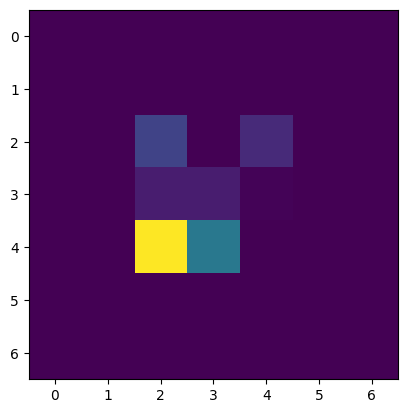

In [18]:
## Test plot on Toy Data 
ToyTumor = melt_spot_and_int(spot1, int1, resize=3, padding=2)
plot_mz(ToyTumor, mz_idx = 2, mz_values = mz_toy) # Plot the third m/z value 

MALDI scan has dimensions: [3 3] 
The number of m/z-values is 3
mz:  mz2


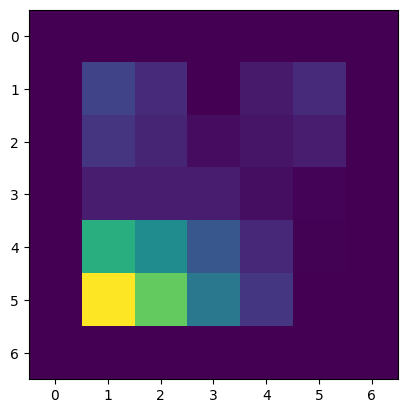

In [19]:
## Test plot on Toy Data - enlarged
ToyTumor_rescaled = melt_spot_and_int(spot1, int1, 5, 1)
plot_mz(ToyTumor_rescaled, 2, mz_toy)

## Functions to Process the Reference Image

Convert it to the same square format as the Intensitys

In [20]:
## Function to embedd reference image in a black square format with width and height 224 + 8
# Input: Reference Image, any dimension
# Output: Square Image with embedded Reference as uint8 Tensor
def resize_and_square(img, resize=224, padding=4):
    h, w = img.shape # height and width
    if(w <= h): # if img is vertical resize to its height 
        resize_factor = h/resize
        w_new = int(w/resize_factor)
        img_resize = cv2.resize(img, (w_new,resize), interpolation=cv2.INTER_AREA) 
        # Note: Different interpolation than int matrices since the reference image is downsized drastically -> cv2 AREA gets smoother results
        # (Source, Accessed 02 July 2026: https://docs.opencv.org/3.4/da/d54/group__imgproc__transform.html#ga5bb5a1fea74ea38e1a5445ca803ff121)
        img_square = np.c_[img_resize, np.zeros((resize, resize-w_new))] # attach zero colums to square
    else: # horizontal image 
        resize_factor = w/resize
        h_new = int(h/resize_factor)
        img_resize = cv2.resize(img, (resize,h_new), interpolation=cv2.INTER_AREA)
        img_square = np.r_[img_resize ,np.zeros((resize-h_new, resize))] # attach zero rows to square

    img_ref_tensor = torch.from_numpy(img_square.astype(np.float32))
    img_ref_tensor = img_ref_tensor.reshape(1, 1, resize, resize) 
    img_ref_tensor = v2.Pad(padding)(img_ref_tensor) 
    return img_ref_tensor

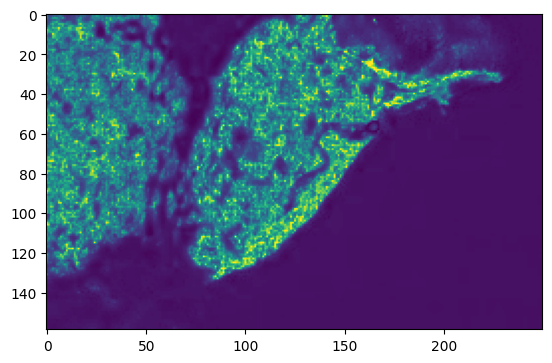

In [21]:
## Example on Toy data (cropped out of a real reference)
path_example_ref = "".join([toy_data_path,"/Toy_Ref.jpg"])
img_test_ref = cv2.cvtColor(cv2.imread(path_example_ref) , cv2.COLOR_BGR2HSV)[:,:,1] # Read Img and tranform in hsv color space. Then extract saturation value
plt.imshow(img_test_ref)

torch.Size([1, 1, 232, 232])


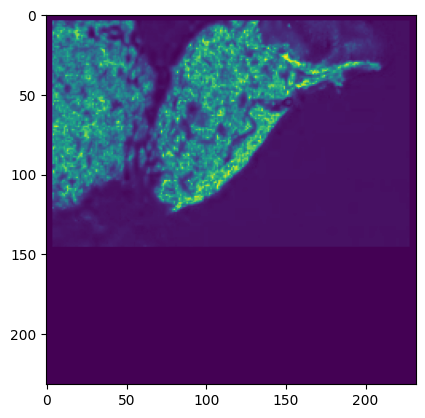

In [22]:
## Reize and Square
img_test_ref_sq = resize_and_square(img_test_ref, resize=224, padding=4)
plot_mz(img_test_ref_sq, mz_idx = 0, mz_print=False)
print(img_test_ref_sq.shape) # Shape is: batch size, color channels, size dim0, size dim1

## Standardize and Scale 
Standardize and Scale Intensitys and Ref (per m/z-value i.e. row) to "color"/intensity range 0-1, and cap them at 99.9% quantile to avoid bias from extreme outliers

In [23]:
def cap_and_scale(M_input_tensor, q=0.999, scale_to = 1): 
    M_copy = M_input_tensor.clone() # create a copy (otherwise the original input matrix will be overwritten)
    for mz in range(M_copy.shape[0]): # iterate over mz values (including Ref)
        img_mz = M_copy[mz]
        quant_mz = torch.quantile(img_mz,q=q)
        img_mz[img_mz > quant_mz] = quant_mz # Set all values higher than q to q
        if(torch.max(img_mz)==0):  # If all values are 0 skip the scaling part
            M_copy[mz] = img_mz
            continue
        img_mz = (img_mz - torch.min(img_mz)) * scale_to  / (torch.max(img_mz) - torch.min(img_mz)) # bring range to 0 to scale_to (usually 1 or 255) 
        M_copy[mz] = img_mz

    return(M_copy)    

In [24]:
## Example
cap_and_scale(ToyTumor)

tensor([[[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0207, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 1.0000, 0.0000, 0.0829, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0829, 0.2900, 0.0829, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000]]],


        [[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.5123, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.1025, 0.0683, 0.0171, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.5123, 1.0000, 0.0512, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000]]],


        [[[0.0000, 0.0000, 0.0000, 0.000

---

## Melt and Save all tumors (Example Data)

In [ ]:
## Wrapper Function for Preprocess and Saving
def preprocess_and_save(size=224):
    os.chdir(raw_data_path)
    mouse_folder_list = [dir for dir in os.listdir() if (os.path.isdir(dir) and not dir.startswith("Toy"))] # extract subdirectories, exclude folders that start with "Toy"
    for mouse_folder in mouse_folder_list: 
        print(mouse_folder, ": Reading", end=" ")
        # Data paths
        path_int = glob.glob(os.path.join(mouse_folder,"*colData*.csv"))[0] 
        path_spot = glob.glob(os.path.join(mouse_folder,"*Reg*.csv"))[0]
        path_ref = glob.glob(os.path.join(mouse_folder,"*.jpg"))[0] # Path for the jpg reference

        # Intensity matrices
        int_matrix = read_int(path_int, skip_rows=0) # If your data contains header lines adjust "skip_rows" (for row and column names is accounted)
        spot_matrix = read_spots(path_spot, skip_rows=0) 
        print("- Processing", end=" ")
        M_melt = melt_spot_and_int(spot_matrix, int_matrix, resize=size)
        
        # Ref img
        img_ref = cv2.imread(path_ref)
        img_ref = cv2.cvtColor(img_ref , cv2.COLOR_BGR2HSV)[:,:,1] # Read Img and tranform in hsv color space. Then extract saturation value
        img_ref_tensor = resize_and_square(img_ref, resize=size)

        # Combine Ref and Intensitys 
        M_combined = torch.concatenate((img_ref_tensor, M_melt))
        M_combined = cap_and_scale(M_combined, q=0.999, scale_to=1)

        torch.save(M_combined, "".join(["../",processed_data_path,"/",mouse_folder,".pt"]))
        
    os.chdir("..")    

In [26]:
### Read and preprocess all tumors in rawdata_folder
preprocess_and_save(size=224)

ExampleTumor1 : Reading - Processing MALDI scan has dimensions: [193  85] 
The number of m/z-values is 99
ExampleTumor2 : Reading - Processing MALDI scan has dimensions: [205  79] 
The number of m/z-values is 99
ExampleTumor3 : Reading - Processing MALDI scan has dimensions: [232  64] 
The number of m/z-values is 99
ExampleTumor4 : Reading - Processing The distances between x values differ: [  20. 1720.]
dist is set to greatest common divisor 20 - Missing spots during 'melt-step' are set to 0
The distances between x values differ: [ 1 86]
dist is set to greatest common divisor 1 - Missing spots during 'melt-step' are set to 0
MALDI scan has dimensions: [267  93] 
The number of m/z-values is 99
ExampleTumor5 : Reading - Processing MALDI scan has dimensions: [175  80] 
The number of m/z-values is 99
ExampleTumor6 : Reading - Processing MALDI scan has dimensions: [175  77] 
The number of m/z-values is 99


## Import and Visualization (Example Tumor 4)

mz:  Ref


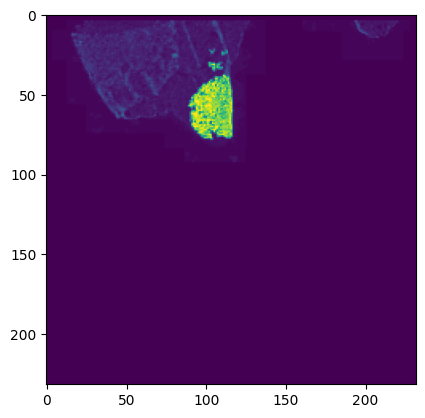

In [27]:
## Plot the Reference (Index 0)
Tumor4 = torch.load("".join([processed_data_path,"/ExampleTumor4.pt"])) #! adjust name to visualize other specimen
plot_mz(Tumor4, 0)

mz:  722.53374619541


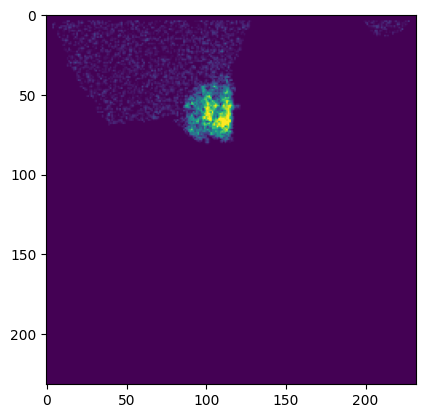

In [28]:
## Plot a m/z-value, here: index 87, m/z 722.534 
plot_mz(Tumor4, 87)